In [4]:
%pip install transformer_lens
%python.exe -m pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
UsageError: Line magic function `%python.exe` not found.


Loading GPT-2 Small...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

c:\Users\shane\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shane\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
`torch_dtype` is deprecated! Use `dtype` instead!
Xet Storage is enabled for this repo, but the 'hf_xet' packa

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer
Extracting residual stream activations at blocks.6.hook_resid_post...
Applying PCA to find 2D geometric structure...
Variance explained by PC1: 23.75%
Variance explained by PC2: 18.48%


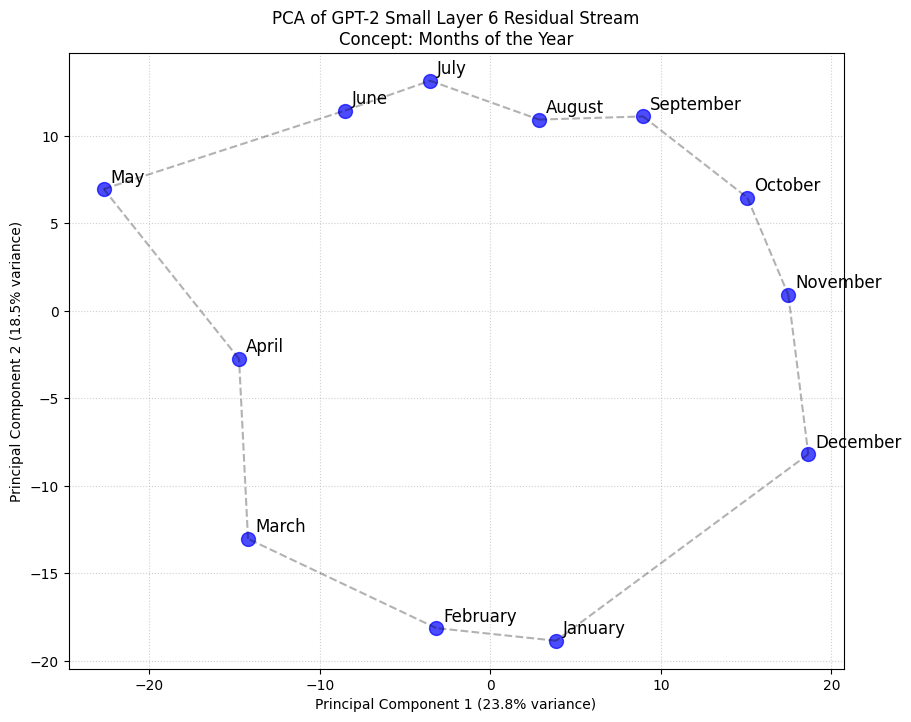

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
from sklearn.decomposition import PCA


# 1. Load the target model
print("Loading GPT-2 Small...")
model = HookedTransformer.from_pretrained("gpt2-small")
    
# 2. Define the synthetic dataset (Days of the Week & Months)
# Using a standardized prefix helps isolate the conceptual representation 
# of the target word rather than just its raw token embedding.
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
months = ["January", "February", "March", "April", "May", "June", 
              "July", "August", "September", "October", "November", "December"]
    
# We will test the 'months' concept for this run
prefix = "The current month is"
prompts = [f"{prefix} {month}" for month in months]
    
# 3. Setup caching for the target layer
target_layer = 6
hook_name = f"blocks.{target_layer}.hook_resid_post"
    
# 4. Run the model and extract activations
print(f"Extracting residual stream activations at {hook_name}...")
    
# We'll store the activation of the final token (the month itself) for each prompt
extracted_activations = []
    
for prompt in prompts:
    # Run with cache returns logits and a cache dictionary
    logits, cache = model.run_with_cache(prompt)
    
    # Extract the specific activation tensor: Shape [batch, seq_len, d_model]
    layer_activations = cache[hook_name]
    
    # We want the activation of the LAST token (-1) in the sequence (the month)
    # Squeeze to remove the batch dimension, resulting in shape [d_model] (which is 768)
    last_token_activation = layer_activations[0, -1, :].detach().cpu().numpy()
    extracted_activations.append(last_token_activation)
        
# Convert list to numpy array: Shape [num_prompts, d_model]
activation_matrix = np.array(extracted_activations)
    
# 5. Apply Dimensionality Reduction (PCA)
print("Applying PCA to find 2D geometric structure...")
pca = PCA(n_components=2)
pca_results = pca.fit_transform(activation_matrix)
    
# Variance explained by the first two components
var_explained = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {var_explained[0]:.2%}")
print(f"Variance explained by PC2: {var_explained[1]:.2%}")
    
# 6. Visualize the Manifold
plt.figure(figsize=(10, 8))
plt.scatter(pca_results[:, 0], pca_results[:, 1], color='blue', s=100, alpha=0.7)
    
# Annotate the points with their respective labels
for i, month in enumerate(months):
    plt.annotate(month, (pca_results[i, 0], pca_results[i, 1]), 
                 fontsize=12, xytext=(5,5), textcoords='offset points')
        
# Optional: Draw lines connecting them in chronological order to highlight the loop
for i in range(len(months)):
    start_idx = i
    end_idx = (i + 1) % len(months)
    plt.plot([pca_results[start_idx, 0], pca_results[end_idx, 0]], 
             [pca_results[start_idx, 1], pca_results[end_idx, 1]], 
             'k--', alpha=0.3)

plt.title(f"PCA of GPT-2 Small Layer {target_layer} Residual Stream\nConcept: Months of the Year")
plt.xlabel(f"Principal Component 1 ({var_explained[0]:.1%} variance)")
plt.ylabel(f"Principal Component 2 ({var_explained[1]:.1%} variance)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
#